<a href="https://colab.research.google.com/github/boodscode237/NeuralNetRefresh/blob/main/random_forests.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

With fast ai

In [2]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [3]:
path = kagglehub.competition_download('titanic')

100%|██████████| 34.1k/34.1k [00:00<00:00, 27.2MB/s]

Extracting files...


In [4]:
import torch, numpy as np, pandas as pd
np.set_printoptions(linewidth=140)
torch.set_printoptions(linewidth=140, sci_mode=False, edgeitems=7)
pd.set_option('display.width', 140)

In [5]:
from fastai.imports import *

In [18]:
import os
df = pd.read_csv(os.path.join(path, 'train.csv'))

modes = df.mode().iloc[0]

In [7]:
import os
from pathlib import Path

if 'path' not in locals():
    import kagglehub
    path = kagglehub.competition_download('titanic')

path = Path(path)

df = pd.read_csv(path/'train.csv')
test_path = path/'test.csv'
if test_path.exists():
    tst_df = pd.read_csv(test_path)
else:
    print(f"test.csv not found in {path}")

modes = df.mode().iloc[0]

With random forest we don't need to greate dummies variables, we instead convert to categorical variables

In [8]:
def proc_data(df):
    df['Fare'] = df.Fare.fillna(0)
    df.fillna(modes, inplace=True)
    df['LogFare'] = np.log1p(df['Fare'])
    df['Embarked'] = pd.Categorical(df.Embarked)
    df['Sex'] = pd.Categorical(df.Sex)

proc_data(df)
proc_data(tst_df)

In [9]:
cont_names = ['Age', 'SibSp', 'Parch', 'LogFare', 'Pclass']
cat_names = ['Sex', 'Embarked']
y_names = 'Survived'

print(f"Continuous features: {cont_names}")
print(f"Categorical features: {cat_names}")
print(f"Target variable: {y_names}")

Continuous features: ['Age', 'SibSp', 'Parch', 'LogFare', 'Pclass']
Categorical features: ['Sex', 'Embarked']
Target variable: Survived


In [11]:
df.Embarked.head()

,Embarked
0,S
1,C
2,S
3,S
4,S


random forest uses binary split

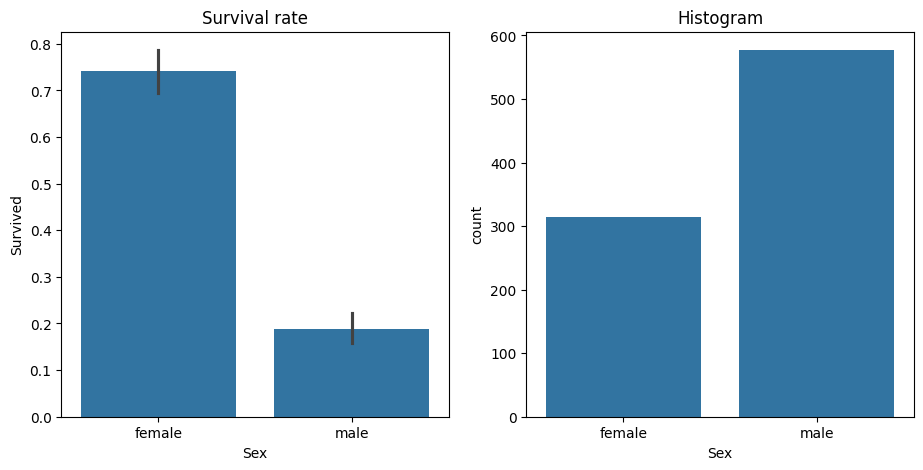

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(11, 5))
sns.barplot(data=df, y="Survived", x="Sex", ax=axs[0]).set(title="Survival rate")
sns.countplot(data=df, x="Sex", ax=axs[1]).set(title="Histogram");

In [15]:
from numpy import random
from sklearn.model_selection import train_test_split

random.seed(42)
trn_df, val_df = train_test_split(df, test_size=0.25)

trn_df[cat_names] = trn_df[cat_names].apply(lambda x: x.cat.codes)
val_df[cat_names] = val_df[cat_names].apply(lambda x: x.cat.codes)

In [16]:
def get_xs_y(df):
    xs = df[cont_names + cat_names].copy()
    return xs, df[y_names]

trn_x, trn_y = get_xs_y(trn_df)
val_x, val_y = get_xs_y(val_df)

print(f"Training features: {trn_x.columns.tolist()}")
print(f"Training shape: {trn_x.shape}")
trn_x.head()

Training features: ['Age', 'SibSp', 'Parch', 'LogFare', 'Pclass', 'Sex', 'Embarked']
Training shape: (668, 7)


,Age,SibSp,Parch,LogFare,Pclass,Sex,Embarked
298,24.00,0,0,3.449988,1,1,2
884,25.00,0,0,2.085672,3,1,2
247,24.00,0,2,2.740840,2,0,2
478,22.00,0,0,2.142510,3,1,2
305,0.92,1,2,5.027492,1,1,2


In [18]:
preds = val_x.Sex==0

In [19]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(val_y, preds)
print(f"Baseline Mean Absolute Error: {mae:.4f}")

accuracy = (preds == val_y).mean()
print(f"Baseline Accuracy: {accuracy:.4f}")

Baseline Mean Absolute Error: 0.2152
Baseline Accuracy: 0.7848


we could look at LogFare

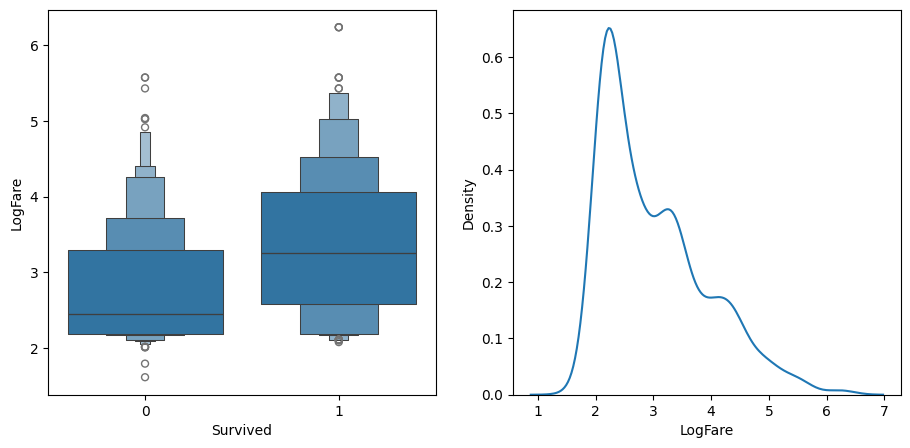

In [22]:
df_fare = trn_df[trn_df.LogFare>0]
fig,axs = plt.subplots(1,2, figsize=(11,5))
sns.boxenplot(data=df_fare, x="Survived", y="LogFare", ax=axs[0])
sns.kdeplot(data=df_fare, x="LogFare", ax=axs[1]);

In [24]:
preds = val_x.LogFare>2.7

In [25]:
mean_absolute_error(val_y, preds)

0.336322869955157

In [26]:
def _side_score(side, y):
    tot = side.sum()
    if tot<=1: return 0
    return y[side].std()*tot

In [28]:
def score(col, y, split):
  lhs = col<=split
  return (_side_score(lhs,y) + _side_score(~lhs,y))/len(y)

In [30]:
score(trn_x["Sex"], trn_y, 0.5)

np.float64(0.4078753098206398)

In [31]:
score(trn_x["LogFare"], trn_y, 2.7)

np.float64(0.4718087395209973)

In [33]:
def iscore(nm, split):
    col = trn_x[nm]
    return score(col, trn_y, split)

from ipywidgets import interact
# Using 'cont_names' which was defined earlier
interact(nm=cont_names, split=15.5)(iscore);

interactive(children=(Dropdown(description='nm', options=('Age', 'SibSp', 'Parch', 'LogFare', 'Pclass'), value…

In [36]:
# Using 'cat_names' which was defined earlier
interact(nm=cat_names, split=2)(iscore);

interactive(children=(Dropdown(description='nm', options=('Sex', 'Embarked'), value='Sex'), IntSlider(value=2,…

lets find the best split for age

In [38]:
nm = "Age"
col = trn_x[nm]
unq = col.unique()
unq.sort()
unq

array([ 0.42,  0.67,  0.75,  0.83,  0.92,  1.  ,  2.  ,  3.  ,  4.  ,  5.  ,  6.  ,  7.  ,  8.  ,  9.  , 10.  , 11.  , 12.  , 13.  , 14.  ,
       14.5 , 15.  , 16.  , 17.  , 18.  , 19.  , 20.  , 21.  , 22.  , 23.  , 24.  , 24.5 , 25.  , 26.  , 27.  , 28.  , 28.5 , 29.  , 30.  ,
       31.  , 32.  , 32.5 , 33.  , 34.  , 34.5 , 35.  , 36.  , 36.5 , 37.  , 38.  , 39.  , 40.  , 40.5 , 41.  , 42.  , 43.  , 44.  , 45.  ,
       45.5 , 46.  , 47.  , 48.  , 49.  , 50.  , 51.  , 52.  , 53.  , 54.  , 55.  , 55.5 , 56.  , 57.  , 58.  , 59.  , 60.  , 61.  , 62.  ,
       64.  , 65.  , 70.  , 70.5 , 74.  , 80.  ])

In [41]:
scores = np.array([score(col, trn_y, o) for o in unq if not np.isnan(o)])
unq[scores.argmin()]

np.float64(6.0)

In [43]:
def min_col(df, nm):
    col,y = df[nm],df[y_names]
    unq = col.dropna().unique()
    scores = np.array([score(col, y, o) for o in unq if not np.isnan(o)])
    idx = scores.argmin()
    return unq[idx],scores[idx]

min_col(trn_df, "Age")

(np.float64(6.0), np.float64(0.47831671750899085))

In [44]:
results = {nm: min_col(trn_df, nm) for nm in cont_names + cat_names}

for nm, (split, score_val) in sorted(results.items(), key=lambda x: x[1][1]):
    print(f"{nm:10}: Split at {split:6.2f} | Score: {score_val:.4f}")

Sex       : Split at   0.00 | Score: 0.4079
Pclass    : Split at   2.00 | Score: 0.4605
LogFare   : Split at   2.44 | Score: 0.4621
Age       : Split at   6.00 | Score: 0.4783
SibSp     : Split at   4.00 | Score: 0.4784
Embarked  : Split at   0.00 | Score: 0.4788
Parch     : Split at   0.00 | Score: 0.4805


decision tree